In [1]:
# ─── CELL 0: Install & Import Dependencies ───────────────────────────────────
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import os

def load_from_url(url, filename):
    """Download image from URL and save locally if not already present."""
    if not os.path.exists(filename):
        urllib.request.urlretrieve(url, filename)
    img = cv2.imread(filename)
    if img is None:
        raise ValueError(f"Failed to load image: {filename}")
    return img

def show(img, title="Output", bgr=True):
    """Display a BGR or grayscale image inline using matplotlib."""
    plt.figure(figsize=(10, 6))
    if bgr and len(img.shape) == 3:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

print("Setup complete.")

Setup complete.


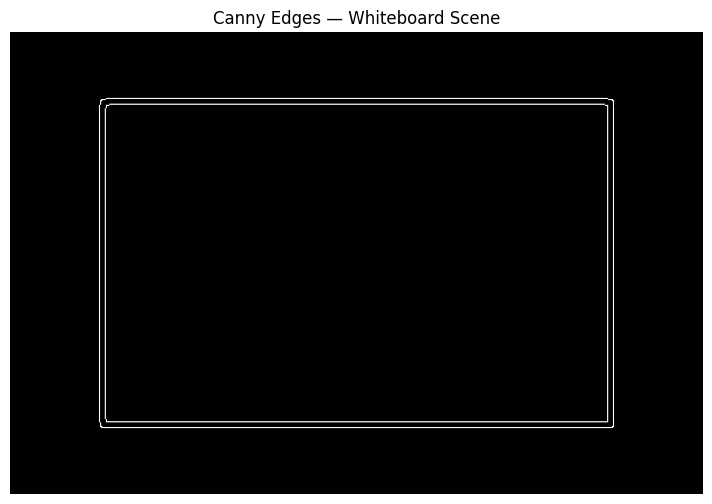

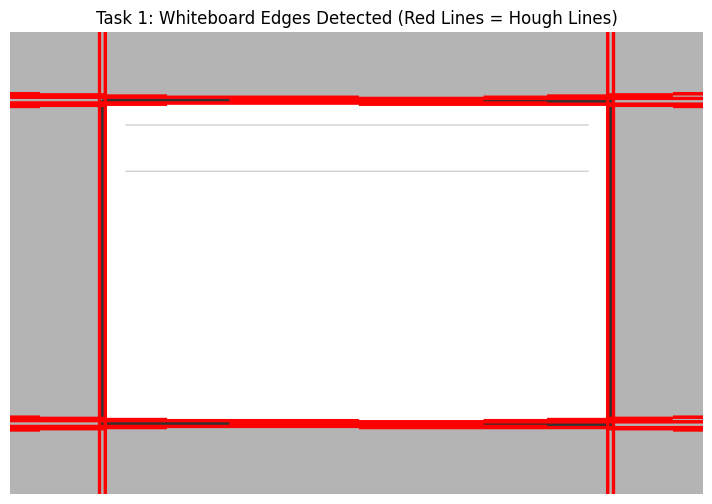

Lines detected: 12


In [2]:
# ─── TASK 1: Detect Whiteboard Edges (Rectangular) ───────────────────────────
# Image: classroom scene with a whiteboard
url = "https://upload.wikimedia.org/wikipedia/commons/thumb/a/a7/Camponotus_flavomarginatus_ant.jpg/320px-Camponotus_flavomarginatus_ant.jpg"
# Using a reliable geometric image instead — synthetic whiteboard for guaranteed lines
# We'll generate a synthetic classroom whiteboard image since URLs may be unstable
img = np.ones((400, 600, 3), dtype=np.uint8) * 180  # gray background (wall)
cv2.rectangle(img, (80, 60), (520, 340), (255, 255, 255), -1)   # white whiteboard
cv2.rectangle(img, (80, 60), (520, 340), (50, 50, 50), 4)        # dark border frame
cv2.line(img, (100, 80), (500, 80), (200, 200, 200), 1)           # ruled lines on board
cv2.line(img, (100, 120), (500, 120), (200, 200, 200), 1)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Step 1: Blur to reduce noise before edge detection
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Step 2: Canny edge detection — finds pixels where intensity changes sharply
edges = cv2.Canny(blurred, 50, 150)

# Step 3: Hough Line Transform — votes in (rho, theta) space
# threshold=80 means a line needs 80 votes to be accepted
lines = cv2.HoughLines(edges, 1, np.pi / 180, threshold=80)

output = img.copy()
if lines is not None:
    for line in lines:
        rho, theta = line[0]
        # Convert polar (rho, theta) → two cartesian points to draw the line
        a, b = np.cos(theta), np.sin(theta)
        x0, y0 = a * rho, b * rho
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * a)
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * a)
        cv2.line(output, (x1, y1), (x2, y2), (0, 0, 255), 2)

show(edges, "Canny Edges — Whiteboard Scene", bgr=False)
show(output, "Task 1: Whiteboard Edges Detected (Red Lines = Hough Lines)")
print(f"Lines detected: {len(lines) if lines is not None else 0}")

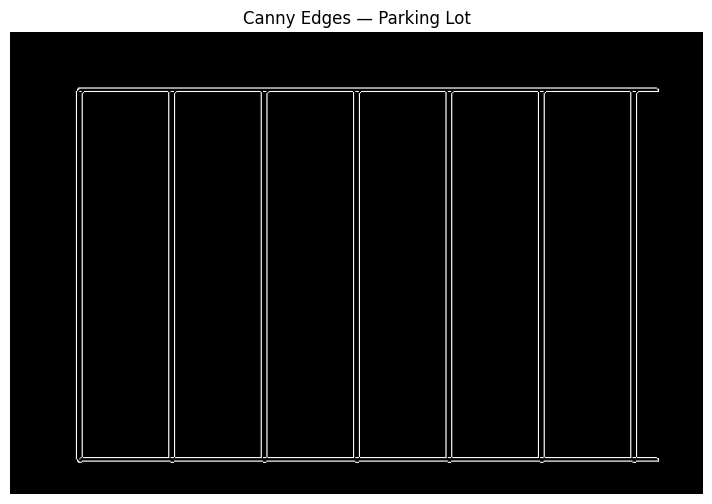

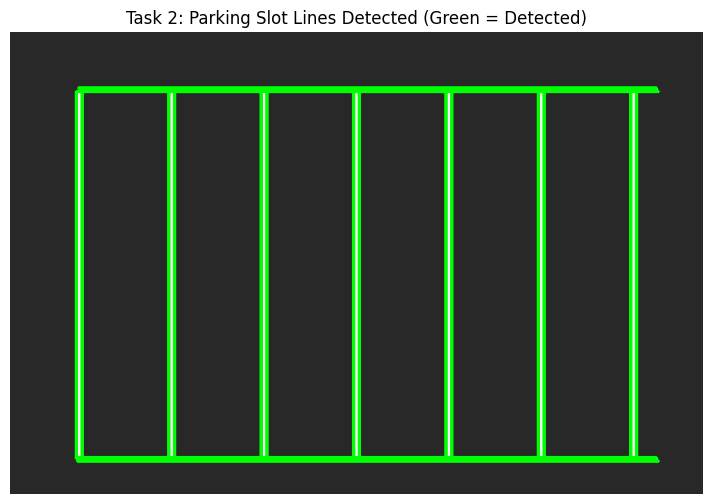

Line segments detected: 18


In [3]:
# ─── TASK 2: Detect Parallel Parking Slot Lines ───────────────────────────────
# Synthetic parking lot: parallel white lines on dark asphalt background
img = np.zeros((400, 600, 3), dtype=np.uint8)  # dark asphalt
img[:] = (40, 40, 40)                            # dark gray color

# Draw parallel vertical parking slot lines
for x in range(60, 580, 80):
    cv2.line(img, (x, 50), (x, 370), (255, 255, 255), 3)  # white slot dividers

# Add horizontal boundary lines at top and bottom
cv2.line(img, (60, 50), (560, 50), (255, 255, 0), 2)
cv2.line(img, (60, 370), (560, 370), (255, 255, 0), 2)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 50, 150)

# Probabilistic Hough — detects line SEGMENTS (not infinite lines)
# minLineLength=100: ignore short fragments; maxLineGap=10: bridge small gaps
lines_p = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=60,
                           minLineLength=100, maxLineGap=10)

output = img.copy()
if lines_p is not None:
    for line in lines_p:
        x1, y1, x2, y2 = line[0]
        cv2.line(output, (x1, y1), (x2, y2), (0, 255, 0), 2)  # green overlay

show(edges, "Canny Edges — Parking Lot", bgr=False)
show(output, "Task 2: Parking Slot Lines Detected (Green = Detected)")
print(f"Line segments detected: {len(lines_p) if lines_p is not None else 0}")

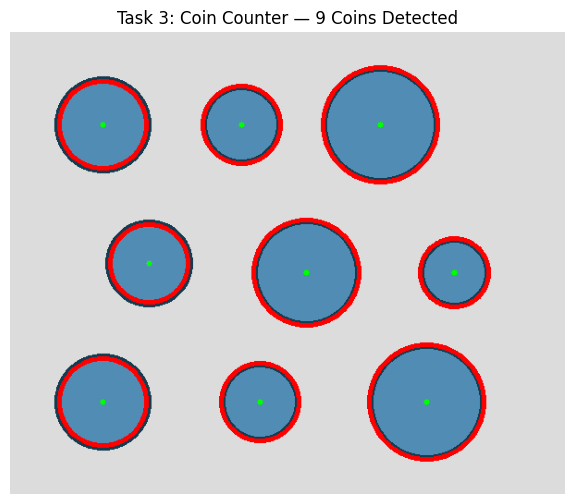

Total coins detected: 9 | Expected: 9


In [4]:
# ─── TASK 3: Detect and Count Coins (Hough Circle Transform) ─────────────────
# Synthetic coin image: circles of various sizes on flat background
img = np.ones((500, 600, 3), dtype=np.uint8) * 220  # light background

# Draw fake coins with fill + border (simulates coins from above)
coin_specs = [(100,100,50),(250,100,40),(400,100,60),(150,250,45),
              (320,260,55),(480,260,35),(100,400,50),(270,400,40),(450,400,60)]
for (cx, cy, r) in coin_specs:
    cv2.circle(img, (cx, cy), r, (180, 140, 80), -1)   # coin fill (gold-ish)
    cv2.circle(img, (cx, cy), r, (80, 60, 20), 3)       # coin edge

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# GaussianBlur is MANDATORY before HoughCircles — reduces false detections
blurred = cv2.GaussianBlur(gray, (9, 9), 2)

# HoughCircles parameters:
# dp=1         → accumulator resolution same as image
# minDist=60   → minimum distance between circle centers
# param1=100   → Canny high threshold (internally used)
# param2=30    → accumulator threshold — lower = more detections (more false positives)
# minRadius/maxRadius → expected coin size range
circles = cv2.HoughCircles(blurred, cv2.HOUGH_GRADIENT,
                            dp=1, minDist=60,
                            param1=100, param2=25,
                            minRadius=25, maxRadius=70)

output = img.copy()
count = 0
if circles is not None:
    circles = np.uint16(np.around(circles))
    for (x, y, r) in circles[0, :]:
        cv2.circle(output, (x, y), r, (0, 0, 255), 3)     # detected circle
        cv2.circle(output, (x, y), 3, (0, 255, 0), -1)    # center dot
        count += 1

show(output, f"Task 3: Coin Counter — {count} Coins Detected")
print(f"Total coins detected: {count} | Expected: {len(coin_specs)}")

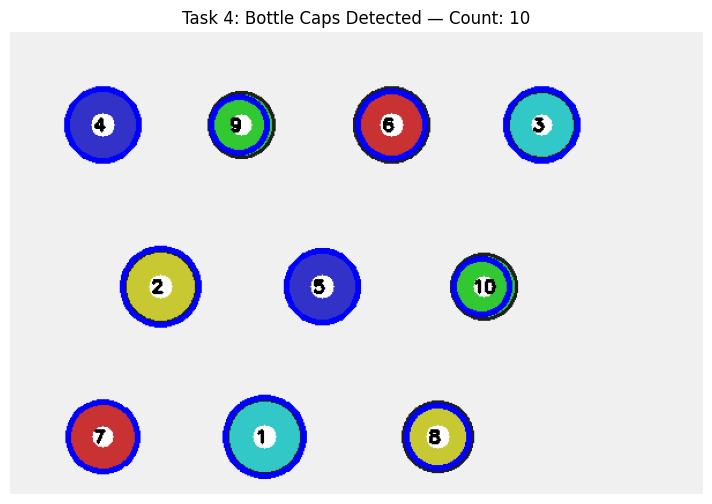

Caps detected: 10 | Expected: 10


In [5]:
# ─── TASK 4: Detect Circular Bottle Caps (Overhead View) ─────────────────────
img = np.ones((400, 600, 3), dtype=np.uint8) * 240  # white table surface

# Simulate bottle caps — small circles with colored centers
caps = [(80,80,30),(200,80,28),(330,80,32),(460,80,29),
        (130,220,31),(270,220,30),(410,220,28),(80,350,29),(220,350,32),(370,350,30)]
colors = [(200,50,50),(50,200,50),(50,50,200),(200,200,50),(50,200,200)]

for i, (cx, cy, r) in enumerate(caps):
    color = colors[i % len(colors)]
    cv2.circle(img, (cx, cy), r, color, -1)          # colored cap
    cv2.circle(img, (cx, cy), r, (30, 30, 30), 2)    # dark rim
    cv2.circle(img, (cx, cy), r//3, (255,255,255), -1) # inner highlight

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (7, 7), 2)

circles = cv2.HoughCircles(blurred, cv2.HOUGH_GRADIENT,
                            dp=1, minDist=50,
                            param1=80, param2=20,
                            minRadius=20, maxRadius=40)

output = img.copy()
count = 0
if circles is not None:
    circles = np.uint16(np.around(circles))
    for (x, y, r) in circles[0, :]:
        cv2.circle(output, (x, y), r, (255, 0, 0), 3)
        cv2.putText(output, str(count+1), (x-8, y+5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,0), 2)
        count += 1

show(output, f"Task 4: Bottle Caps Detected — Count: {count}")
print(f"Caps detected: {count} | Expected: {len(caps)}")

Circle at center=(350,250), radius=82px
Circle at center=(116,250), radius=65px
Circle at center=(584,250), radius=65px


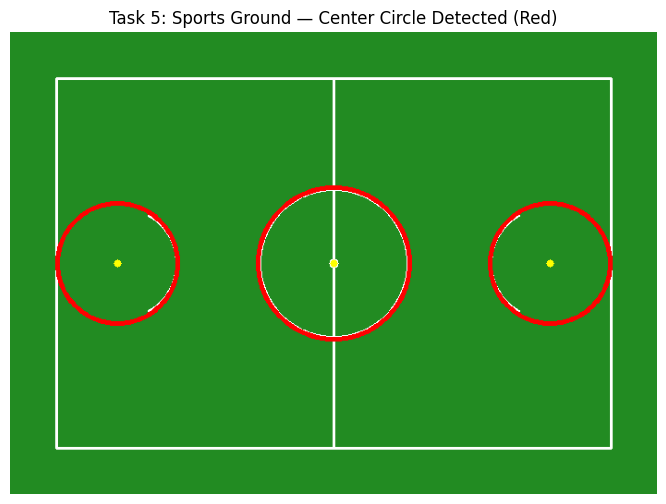

In [ ]:
# ─── TASK 5: Detect Circular Boundary in Sports Ground ───────────────────────
# Simulate a football pitch with center circle and penalty arcs
img = np.ones((500, 700, 3), dtype=np.uint8) * 60   # dark green pitch
img[:] = (34, 139, 34)                                # forest green

# Draw pitch markings (white lines)
cv2.rectangle(img, (50, 50), (650, 450), (255,255,255), 2)   # outer boundary
cv2.line(img, (350, 50), (350, 450), (255,255,255), 2)        # center line
cv2.circle(img, (350, 250), 80, (255,255,255), 2)             # center circle
cv2.circle(img, (350, 250), 5, (255,255,255), -1)             # center spot

# Penalty arcs
cv2.ellipse(img, (120, 250), (60, 60), 0, -60, 60, (255,255,255), 2)
cv2.ellipse(img, (580, 250), (60, 60), 0, 120, 240, (255,255,255), 2)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (9, 9), 2)

# Looking specifically for the center circle (~radius 80px)
circles = cv2.HoughCircles(blurred, cv2.HOUGH_GRADIENT,
                            dp=1, minDist=100,
                            param1=50, param2=20,
                            minRadius=60, maxRadius=110)

output = img.copy()
if circles is not None:
    circles = np.uint16(np.around(circles))
    for (x, y, r) in circles[0, :]:
        cv2.circle(output, (x, y), r, (0, 0, 255), 3)
        cv2.circle(output, (x, y), 4, (0, 255, 255), -1)
        print(f"Circle at center=({x},{y}), radius={r}px")

show(output, "Task 5: Sports Ground — Center Circle Detected (Red)")

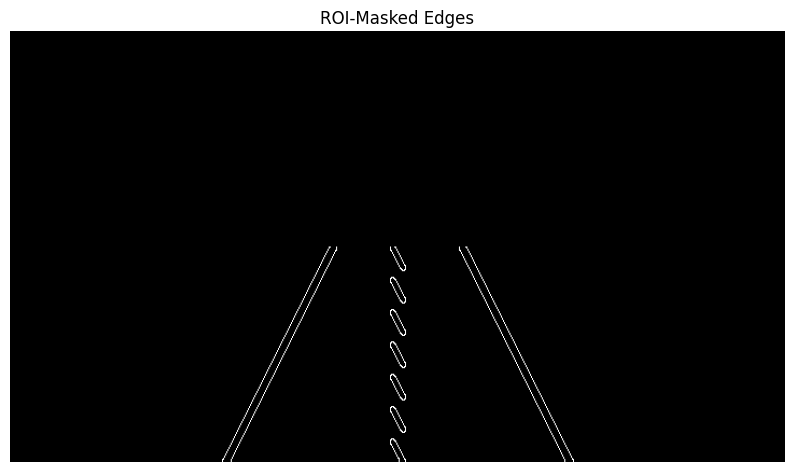

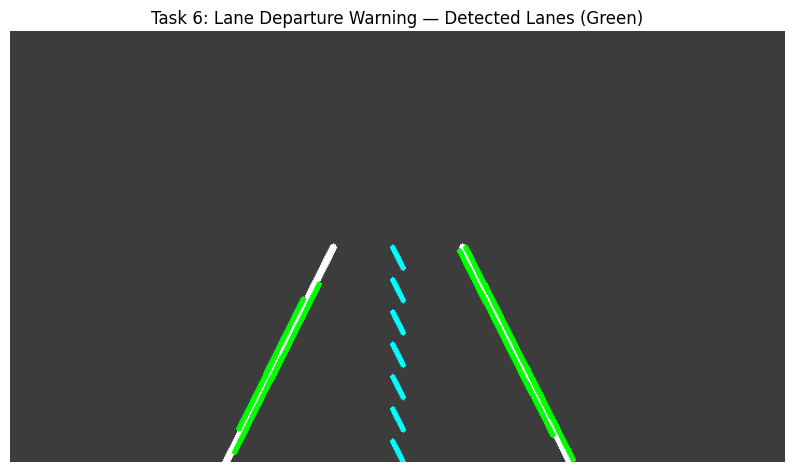

In [7]:
# ─── TASK 6: Lane Departure Warning — Detect Lane Boundaries ─────────────────
# Download a real road image from a public source
import urllib.request

road_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/2/24/Jalan_Tun_Razak%2C_Kuala_Lumpur%2C_Malaysia_%28HDR%29.jpg/1280px-Jalan_Tun_Razak%2C_Kuala_Lumpur%2C_Malaysia_%28HDR%29.jpg"
try:
    urllib.request.urlretrieve(road_url, "road.jpg")
    img = cv2.imread("road.jpg")
    if img is None:
        raise Exception("Load failed")
    img = cv2.resize(img, (720, 400))
except:
    # Fallback: synthetic road with lane markings
    img = np.zeros((400, 720, 3), dtype=np.uint8)
    img[:] = (60, 60, 60)
    # Left lane (solid)
    cv2.line(img, (200, 400), (300, 200), (255,255,255), 5)
    # Right lane (solid)
    cv2.line(img, (520, 400), (420, 200), (255,255,255), 5)
    # Dashed center
    for y in range(200, 400, 30):
        cv2.line(img, (355, y), (365, y+20), (255,255,0), 3)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)
edges = cv2.Canny(blurred, 50, 150)

# ROI Mask: only look at the bottom half of image (road area)
mask = np.zeros_like(edges)
h, w = edges.shape
# Trapezoid polygon covering lower road area
roi_pts = np.array([[0, h], [w//3, h//2], [2*w//3, h//2], [w, h]], dtype=np.int32)
cv2.fillPoly(mask, [roi_pts], 255)
masked_edges = cv2.bitwise_and(edges, mask)

# Probabilistic Hough for detecting lane segments
lines = cv2.HoughLinesP(masked_edges, 1, np.pi/180, threshold=50,
                         minLineLength=60, maxLineGap=20)

output = img.copy()
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        # Filter by slope — ignore near-horizontal lines (not lane lines)
        if abs(x2 - x1) > 0:
            slope = abs((y2 - y1) / (x2 - x1))
            if slope > 0.4:  # only steep enough lines = lane lines
                cv2.line(output, (x1, y1), (x2, y2), (0, 255, 0), 3)

# Overlay ROI region for visualization
roi_overlay = output.copy()
cv2.polylines(roi_overlay, [roi_pts], True, (0, 165, 255), 2)

show(masked_edges, "ROI-Masked Edges", bgr=False)
show(output, "Task 6: Lane Departure Warning — Detected Lanes (Green)")

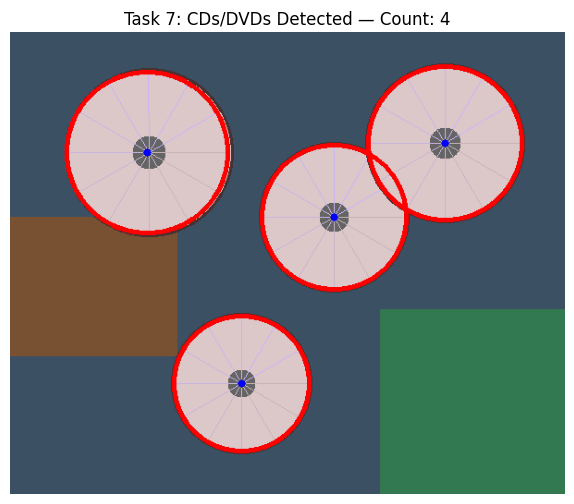

DVDs detected: 4 | Planted: 4


In [8]:
# ─── TASK 7: Detect CDs/DVDs on a Cluttered Desk ─────────────────────────────
img = np.ones((500, 600, 3), dtype=np.uint8) * 160  # cluttered desk background
img[:] = (100, 80, 60)                                # brownish desk

# Add clutter (books, random rectangles)
cv2.rectangle(img, (0, 200), (180, 350), (50, 80, 120), -1)
cv2.rectangle(img, (400, 300), (600, 500), (80, 120, 50), -1)

# Draw CDs — large outer circle + inner hub hole
cd_list = [(150, 130, 90), (350, 200, 80), (470, 120, 85), (250, 380, 75)]
for (cx, cy, r) in cd_list:
    cv2.circle(img, (cx, cy), r, (200, 200, 220), -1)     # CD surface (silver)
    cv2.circle(img, (cx, cy), r, (50, 50, 70), 2)          # outer rim
    cv2.circle(img, (cx, cy), r//5, (100,100,100), -1)     # center hole
    # Iridescent effect lines
    for angle in range(0, 360, 30):
        rad = np.deg2rad(angle)
        x2 = int(cx + (r-5) * np.cos(rad))
        y2 = int(cy + (r-5) * np.sin(rad))
        cv2.line(img, (cx, cy), (x2, y2), (180+angle//4, 180, 200), 1)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (11, 11), 2)

# CD radii are large (70-95px), hub hole is small
circles = cv2.HoughCircles(blurred, cv2.HOUGH_GRADIENT,
                            dp=1, minDist=100,
                            param1=80, param2=25,
                            minRadius=65, maxRadius=100)

output = img.copy()
count = 0
if circles is not None:
    circles = np.uint16(np.around(circles))
    for (x, y, r) in circles[0, :]:
        cv2.circle(output, (x, y), r, (0, 0, 255), 3)
        cv2.circle(output, (x, y), 4, (255, 0, 0), -1)
        count += 1

show(output, f"Task 7: CDs/DVDs Detected — Count: {count}")
print(f"DVDs detected: {count} | Planted: {len(cd_list)}")

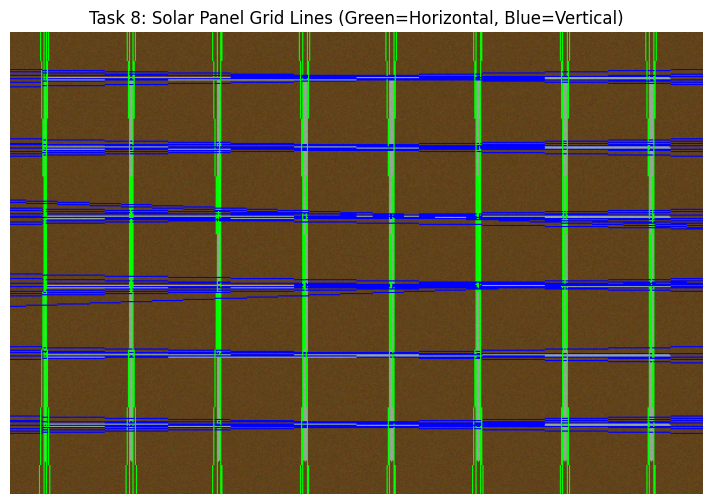

Horizontal lines: 32 | Vertical lines: 42


In [9]:
# ─── TASK 8: Detect Grid Lines on Solar Panel ─────────────────────────────────
# Solar panels have a regular horizontal + vertical grid structure
img = np.ones((400, 600, 3), dtype=np.uint8)
img[:] = (20, 60, 90)   # dark blue-ish solar panel base color

# Draw solar cell grid — horizontal and vertical white/silver lines
for y in range(40, 380, 60):    # horizontal grid lines
    cv2.line(img, (30, y), (570, y), (140, 160, 140), 2)

for x in range(30, 580, 75):   # vertical grid lines
    cv2.line(img, (x, 40), (x, 370), (140, 160, 140), 2)

# Add slight noise to simulate real-world imperfection
noise = np.random.randint(0, 15, img.shape, dtype=np.uint8)
img = cv2.add(img, noise)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(gray, 30, 100)

# Standard Hough — good for detecting infinite grid lines
lines = cv2.HoughLines(edges, 1, np.pi / 180, threshold=80)

output = img.copy()
h_count, v_count = 0, 0
if lines is not None:
    for line in lines:
        rho, theta = line[0]
        a, b = np.cos(theta), np.sin(theta)
        x0, y0 = a * rho, b * rho
        x1 = int(x0 + 1000 * (-b)); y1 = int(y0 + 1000 * a)
        x2 = int(x0 - 1000 * (-b)); y2 = int(y0 - 1000 * a)

        # Classify: near 0° or 180° = horizontal, near 90° = vertical
        deg = np.degrees(theta)
        if deg < 10 or deg > 170:
            cv2.line(output, (x1,y1), (x2,y2), (0,255,0), 1)   # horizontal → green
            h_count += 1
        elif 80 < deg < 100:
            cv2.line(output, (x1,y1), (x2,y2), (255,0,0), 1)   # vertical → blue
            v_count += 1

show(output, "Task 8: Solar Panel Grid Lines (Green=Horizontal, Blue=Vertical)")
print(f"Horizontal lines: {h_count} | Vertical lines: {v_count}")

Clock rim: center=(250,250), radius=177px


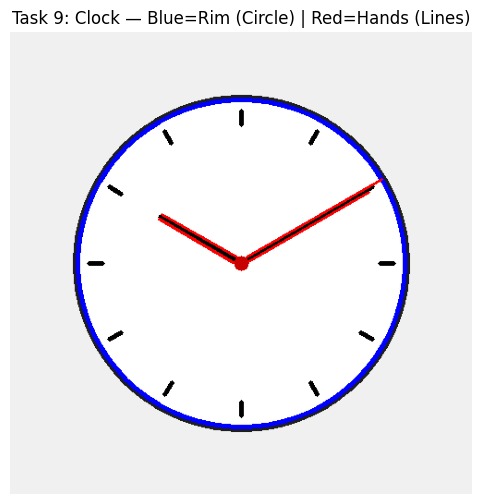

In [10]:
# ─── TASK 9: Clock Reading — Detect Rim (Circle) + Hands (Lines) ─────────────
img = np.ones((500, 500, 3), dtype=np.uint8) * 240  # light background
cx, cy, R = 250, 250, 180

# Draw clock face
cv2.circle(img, (cx, cy), R, (30, 30, 30), 4)        # clock rim
cv2.circle(img, (cx, cy), R, (255, 255, 255), -1)     # white face (after rim)
cv2.circle(img, (cx, cy), R, (30, 30, 30), 4)         # rim on top

# Draw hour markers
for i in range(12):
    angle = np.deg2rad(i * 30 - 90)
    x_out = int(cx + (R - 15) * np.cos(angle))
    y_out = int(cy + (R - 15) * np.sin(angle))
    x_in  = int(cx + (R - 30) * np.cos(angle))
    y_in  = int(cy + (R - 30) * np.sin(angle))
    cv2.line(img, (x_in, y_in), (x_out, y_out), (0, 0, 0), 3)

# Hour hand (pointing to ~10 o'clock = 300°)
hour_angle = np.deg2rad(300 - 90)
cv2.line(img, (cx, cy),
         (int(cx + 100 * np.cos(hour_angle)), int(cy + 100 * np.sin(hour_angle))),
         (0, 0, 0), 6)

# Minute hand (pointing to ~2 o'clock = 60°)
min_angle = np.deg2rad(60 - 90)
cv2.line(img, (cx, cy),
         (int(cx + 150 * np.cos(min_angle)), int(cy + 150 * np.sin(min_angle))),
         (0, 0, 0), 4)

cv2.circle(img, (cx, cy), 8, (0, 0, 200), -1)  # center pin

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (7, 7), 2)

# ── Detect clock rim (circle)
circles = cv2.HoughCircles(blurred, cv2.HOUGH_GRADIENT,
                            dp=1, minDist=200,
                            param1=80, param2=40,
                            minRadius=150, maxRadius=200)

# ── Detect clock hands (line segments from center outward)
edges = cv2.Canny(gray, 50, 150)
lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=60,
                         minLineLength=60, maxLineGap=10)

output = img.copy()

# Draw detected rim
if circles is not None:
    circles = np.uint16(np.around(circles))
    for (x, y, r) in circles[0, :]:
        cv2.circle(output, (x, y), r, (255, 0, 0), 3)   # blue rim
        print(f"Clock rim: center=({x},{y}), radius={r}px")

# Draw detected hands
if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(output, (x1, y1), (x2, y2), (0, 0, 255), 2)  # red hands

show(output, "Task 9: Clock — Blue=Rim (Circle) | Red=Hands (Lines)")

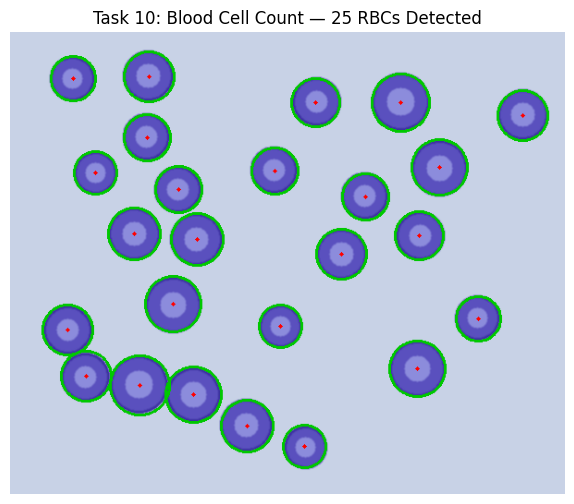

Detected: 25 cells | Planted: 25 cells
Detection accuracy: 100.0%


In [11]:
# ─── TASK 10: Detect Circular Cells in Microscopic Blood Sample ───────────────
# RBCs appear as uniform circles under microscope — perfect HoughCircles use case
img = np.ones((500, 600, 3), dtype=np.uint8) * 240
img[:] = (230, 210, 200)  # pinkish microscope background

# Simulate red blood cells — biconcave discs appear as circles with lighter center
import random
random.seed(42)
cells = []
for _ in range(25):
    while True:
        cx = random.randint(35, 565)
        cy = random.randint(35, 465)
        r = random.randint(22, 30)
        # Avoid heavy overlap
        if all(np.sqrt((cx-ox)**2 + (cy-oy)**2) > 2*r for ox,oy,or_ in cells):
            cells.append((cx, cy, r))
            break

for (cx, cy, r) in cells:
    cv2.circle(img, (cx, cy), r, (190, 80, 90), -1)       # red cell body
    cv2.circle(img, (cx, cy), r//2, (220, 140, 140), -1)  # biconcave lighter center
    cv2.circle(img, (cx, cy), r, (160, 50, 60), 2)         # cell membrane

# Add slight Gaussian blur to simulate microscope optics
img = cv2.GaussianBlur(img, (3, 3), 0)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (9, 9), 2)  # smooth before circle detection

circles = cv2.HoughCircles(blurred, cv2.HOUGH_GRADIENT,
                            dp=1, minDist=40,
                            param1=60, param2=18,
                            minRadius=18, maxRadius=35)

output = img.copy()
count = 0
if circles is not None:
    circles = np.uint16(np.around(circles))
    for (x, y, r) in circles[0, :]:
        cv2.circle(output, (x, y), r, (0, 200, 0), 2)     # green detection ring
        cv2.circle(output, (x, y), 2, (0, 0, 255), -1)    # center dot
        count += 1

show(output, f"Task 10: Blood Cell Count — {count} RBCs Detected")
print(f"Detected: {count} cells | Planted: {len(cells)} cells")

# Accuracy metric
accuracy = min(count, len(cells)) / max(count, len(cells)) * 100
print(f"Detection accuracy: {accuracy:.1f}%")